# Task 4 - Anomaly detection using autoencoders

### <span style="color:red">Deadline: Tuesday, July 1, 2025 at 11:59 p.m.</span>

# IMPORTANT SUBMISSION INSTRUCTIONS

- When you're done, download the notebook and rename it to task4_name.ipynb
- Only submit the `ipynb` file, no other file is required.
- The deadline is strict.
- Minimal requirement for passing: solving all code cells.

Implementation
- Do not change the cells which are marked as "Do not change", similarly write your solution to the marked cells.

# Topics

In this exercise sheet, you will:
- Work with a dataset for `dynamic behavior analysis of automotive software systems`.
- Implement autoencoders (AEs) for unsupervised anomaly detection.
- Compare MLP-based and CNN-based AEs.
- Vary architecture to improve model performance.
- Apply scheduled learning rate.
- Evaluate the performance of the model.

*We are looking forward to seeing your solutions! Have fun!*

# Related publications
 - Abboush, M.; Bamal, D.; Knieke, C.; Rausch, A. Hardware-in-the-Loop-Based Real-Time Fault Injection Framework for Dynamic Behavior Analysis of Automotive Software Systems. Sensors 2022, 22, 1360. https://doi.org/10.3390/s22041360

 - Abboush, M.; Bamal, D.; Knieke, C.; Rausch, A. Intelligent Fault Detection and Classification Based on Hybrid Deep Learning Methods for Hardware-in-the-Loop Test of Automotive Software Systems. Sensors 2022, 22, 4066. https://doi.org/10.3390/s22114066

## Tutorials

Some python libraries are required to accomplish the tasks assigned in this homework. If you feel like you need to follow a tutorial before, feel free to do so:
*   [Scikit-learn Tutorials](https://scikit-learn.org/stable/tutorial/index.html)
*   [TensorFlow Tutorials](https://www.tensorflow.org/tutorials)
*   [Matplotlib Tutorials](https://matplotlib.org/stable/tutorials/index.html)

## Imports

In [1]:
import numpy as np
import pandas as pd
import glob

import tensorflow as tf
from tensorflow.keras import models, layers, optimizers, losses, callbacks
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 24
np.random.seed(SEED)

## System checks


In [2]:
gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')
print(gpus)
print(cpus)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


Choose your device for computation. CPU or one of your CUDA devices.

In [3]:
tf.config.set_visible_devices(gpus, 'GPU')

# Anomaly detection via autoencoders

Anomaly detection is a technique used to identify abnormal or anomalous patterns within a dataset. Autoencoders are neural networks that are trained to reconstruct their input data, typically by learning a compressed representation of the data in an intermediate layer called the **bottleneck layer**.

Anomalies can be identified using autoencoders by comparing the input data to the reconstructed output, as anomalies often result in a higher reconstruction error. In this task, we employ autoencoders for anomaly detection in automotive
software systems.


# Subtask 2.1

## Loading the dataset and pre-processing

The dataset consists of time-series sensor measurements of healthy and faulty operation of the system.<br>
There are three different behaviors available for healthy data: ['JC08', 'JP10', 'FP75'].<br>
And, there are two faulty data for each healthy behavior.<br><br>

The fault type in each file is as following:

| File Prefix | Fault type| Fault Meaning|
|------|------|------|
| GainRPM | Increasing RPM by X2 |  The motor rotations per minute is not behaving normally |
| OffsetACC | Increasing Acceleration by +5 | The Gas pedal is letting more gas in than normal |

In [4]:
# unzip data to Data folder if not extracted

import zipfile

with zipfile.ZipFile("Data.zip", "r") as z:
     z.extractall("./")

In [5]:
# list of available behaviors
data_dir = "./Data/"
behaviors = [i.split("-")[-1].removesuffix(".csv") for i in glob.glob(data_dir + f'Healthy*.csv')]
behaviors

['FP75', 'JC08', 'JP10']

In [16]:
# read healthy and faulty data where a list of data frames have the healthy and faulty behavior within the same list
# this helps later when scaling and visualizing the data

dfs = []

for b in behaviors:
    dfs.append([])

    # read training data
    dfs[-1].append(pd.read_csv(glob.glob(data_dir + f'Healthy*{b}.csv')[0]))

    # read testing data
    for test_df in glob.glob(data_dir + f'[!Healthy]*{b}.csv'):
        dfs[-1].append(pd.read_csv(test_df))

In [38]:
df_size = len(dfs)
df_size

3

In [45]:
dfs[2][2].head()

       time  Pos_Throttle[%]  T_Out_Engine[degC]  Trq_MeanEff_Engine[Nm]  \
0  0.000000         0.029281          457.534054               29.851018   
1  0.050000         0.562290          461.076639               -8.022001   
2  0.100001         2.048030          459.329790              -20.334204   
3  0.150002         2.281940          458.276210               -9.370919   
4  0.200003         2.031862          460.874658                3.068781   

   n_Engine[rpm]   p_InMan[Pa]  p_Rail[bar]  v_vehicle[km|h]  label  
0     846.401623  56403.365084   122.630957    8.695555e-322   True  
1     818.803156  51521.612395   126.674044    8.695555e-322   True  
2     785.260771  48601.485300   122.904830    8.695555e-322   True  
3     778.152055  46389.858643   118.579931    8.695555e-322   True  
4     792.128327  44183.476771   117.786940    8.695555e-322   True  


In [48]:
# Continue with checking the missing value and the data type of each column.

for i in range(3):
  for j in range(3):
    dfs[i][j].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   time                    5000 non-null   float64
 1   Pos_Throttle[%]         5000 non-null   float64
 2   T_Out_Engine[degC]      5000 non-null   float64
 3   Trq_MeanEff_Engine[Nm]  5000 non-null   float64
 4   n_Engine[rpm]           5000 non-null   float64
 5   p_InMan[Pa]             5000 non-null   float64
 6   p_Rail[bar]             5000 non-null   float64
 7   v_vehicle[km|h]         5000 non-null   float64
 8   label                   5000 non-null   bool   
dtypes: bool(1), float64(8)
memory usage: 317.5 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4992 entries, 0 to 4991
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   time                    4992 non-null   flo

**According the result, we can see: No missing value.(Good News)**

#### TODO

- Visualize `All Features` of one healthy data and its two faulty data time-series in a grid of plots.

**Note:** Do not forget to add title, axis labels and a legend!
This applies in general, please keep in mind.

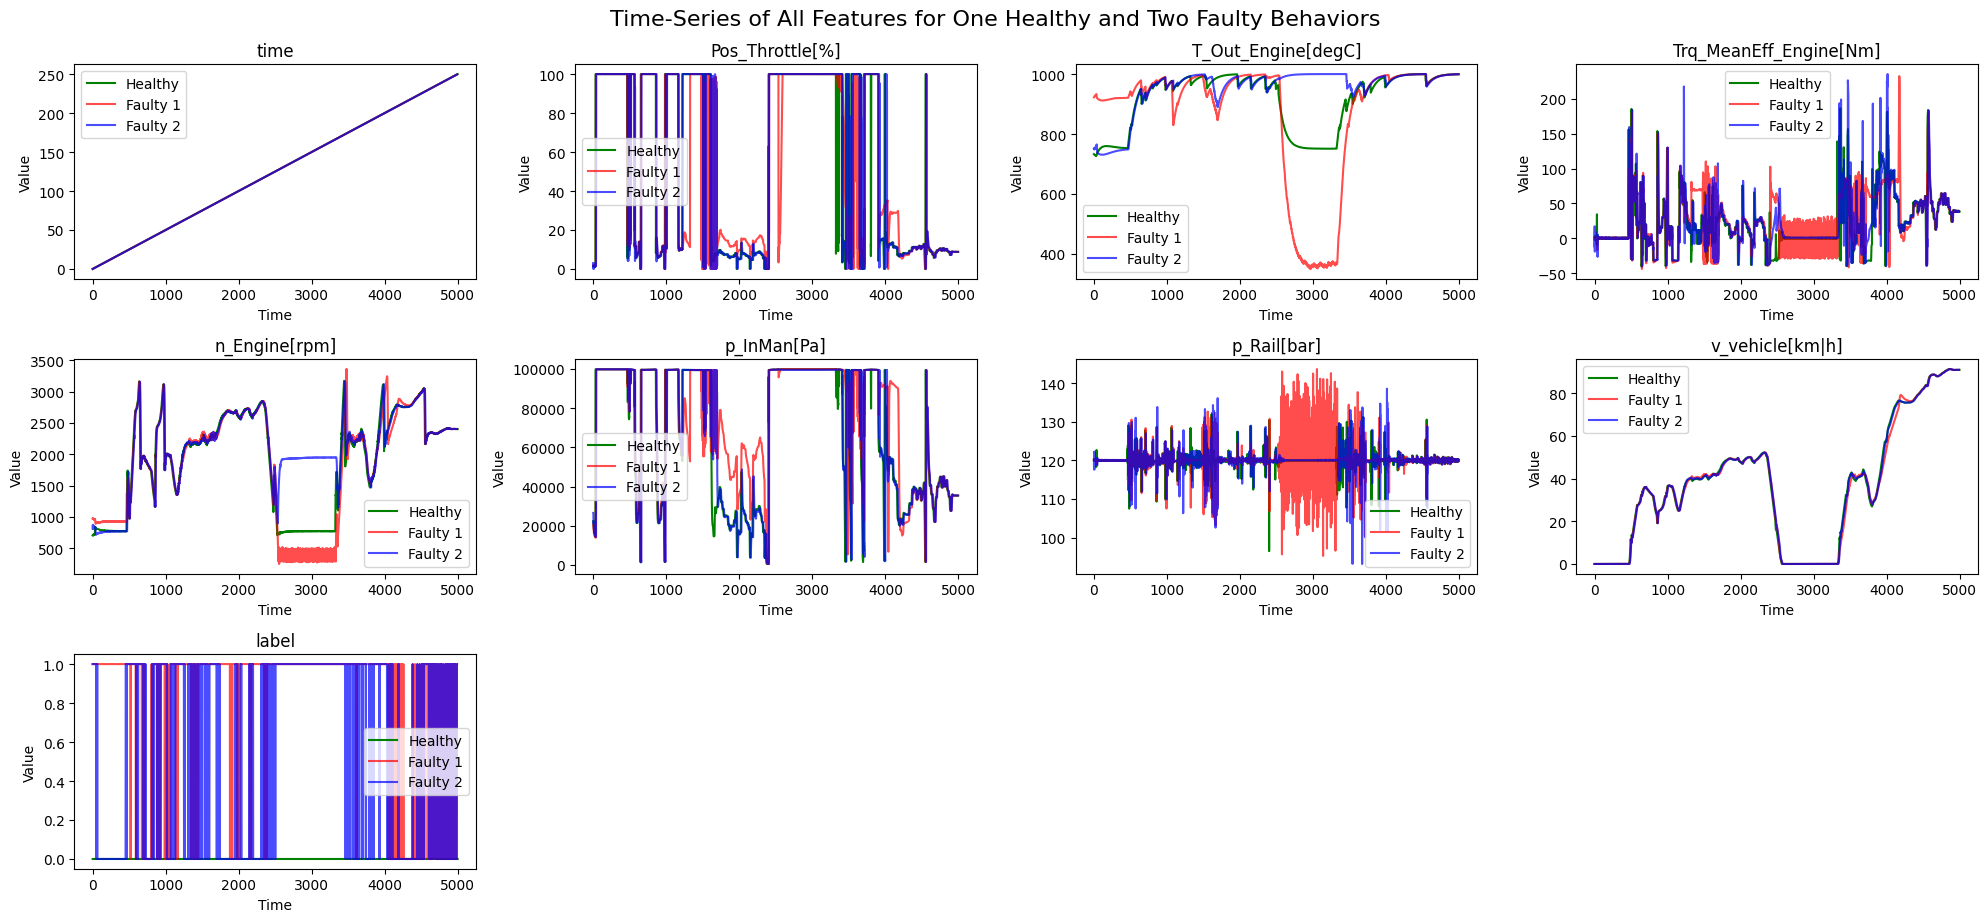

In [49]:

import matplotlib.pyplot as plt

# healty and faulty data
healthy_df = dfs[0][0]
faulty_df_1 = dfs[0][1]
faulty_df_2 = dfs[0][2]

# feature
features = healthy_df.columns
n_features = len(features)

# size of Grid
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

# create plot
plt.figure(figsize=(n_cols * 5, n_rows * 3))

for idx, feature in enumerate(features):
    plt.subplot(n_rows, n_cols, idx + 1)
    plt.plot(healthy_df[feature], label='Healthy', color='green')
    plt.plot(faulty_df_1[feature], label='Faulty 1', color='red', alpha=0.7)
    plt.plot(faulty_df_2[feature], label='Faulty 2', color='blue', alpha=0.7)
    plt.title(feature)
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()

plt.tight_layout()
plt.suptitle("Time-Series of All Features for One Healthy and Two Faulty Behaviors", fontsize=16, y=1.02)
plt.show()

## Pre-processing

#### TODO
- Scale the data using `min-max scaler` to scale each healthy behavior and its faulty data.
- Extract the labels to `y_train` for healthy data and `y_test` for faulty data.<br>
- Do not forget to drop **"time"** and **"label"** columns before scaling



In [85]:
X_train = []
X_test = []

y_train = []
y_test = []

for df in dfs:
    # The scaler should be different for each behavior
    scaler = MinMaxScaler()

    # Healthy data
    healthy_df = df[0].copy()
    y_train.append(healthy_df["label"].values)
    healthy_features = healthy_df.drop(columns=["time", "label"])

    # Fit scaler only on healthy data
    scaled_healthy = scaler.fit_transform(healthy_features)
    X_train.append(scaled_healthy)

    # Faulty data
    for faulty_df in df[1:]:
        faulty_df = faulty_df.copy()
        y_test.append(faulty_df["label"].values)
        faulty_features = faulty_df.drop(columns=["time", "label"])

        # Use same scaler (fitted on healthy)
        scaled_faulty = scaler.transform(faulty_features)
        X_test.append(scaled_faulty)

Since we are working with time-series data, it is beneficial to consider a sequence of time steps as the input of the model. In this way it is possible to exploit and learn the temporal dependencies in the data.

To this end, let us consider a sliding window with the length of $\ell$ and slide it over the whole time series with a stride of $s$ to generate our sequences. In this way, we will have:

$ X_0 = [x_0, ..., x_{\ell}]$

$ X_1 = [x_s, ..., x_{\ell+s}]$

$ X_2 = [x_{2s}, ..., x_{\ell+2s}]$

...

$ X_n = [x_{n\times s}, ..., x_{\ell+ n \times s}]$

as our input samples, where $x_t \in \mathbb{R}^p$ is the state of the system at time $t$.

In [86]:
def make_sequences(data, l, stride = 1):
    sequences = [data[i:i+l] for i in range(0, len(data) - l, stride)]
    return np.array(sequences)

#### TODO
 - Use the function above (`make_sequences`) to generate sequences. Use the sequence length of $\ell = 32$ and stride of 1 for healthy data (for training and validation) and stride of $\ell$ for faulty data (for testing).
 - Consider 80% of the healthy data for training and 20\% of it for validation.

**Note that we fit our model to the healthy data. After the training, we will employ the model to detect anomalies in the faulty time series.**

In [87]:
l = 32
N_train = int(X_train[0].shape[0] * 0.8 / l)

X_seq_train = []
y_seq_train = []

X_val = []
y_val = []

for i in range(len(X_train)):
    X = X_train[i]
    y = y_train[i]

    # Split %80 for training, %20 for validation
    X_train_split = X[:N_train * l]
    y_train_split = y[:N_train * l]

    X_val_split = X[N_train * l:]
    y_val_split = y[N_train * l:]

    # Sequence
    X_seq_train.append(make_sequences(X_train_split, l, stride=1))
    y_seq_train.append(make_sequences(y_train_split, l, stride=1))

    X_val.append(make_sequences(X_val_split, l, stride=1))
    y_val.append(make_sequences(y_val_split, l, stride=1))

# Test data (faulty)
X_seq_test = []
y_seq_test = []

for i in range(len(X_test)):
    X = X_test[i]
    y = y_test[i]

    # Stride = l
    X_seq_test.append(make_sequences(X, l, stride=l))
    y_seq_test.append(make_sequences(y, l, stride=l))


In [88]:
# print the shape of each split

# healthy data - train/val
for i in range(len(X_seq_train)):
    print(f"Behavior {i}:")
    print(f"  Train shape: {X_seq_train[i].shape}")
    print(f"  Val shape:   {X_val[i].shape}")

# faulty data - test
for i in range(len(X_seq_test)):
    print(f"  Test shape:  {X_seq_test[i].shape}")


Behavior 0:
  Train shape: (3968, 32, 7)
  Val shape:   (968, 32, 7)
Behavior 1:
  Train shape: (3968, 32, 7)
  Val shape:   (968, 32, 7)
Behavior 2:
  Train shape: (3968, 32, 7)
  Val shape:   (968, 32, 7)
  Test shape:  (155, 32, 7)
  Test shape:  (155, 32, 7)
  Test shape:  (155, 32, 7)
  Test shape:  (155, 32, 7)
  Test shape:  (155, 32, 7)
  Test shape:  (155, 32, 7)


#### TODO
Your data splits shapes should be something  like:
- Train 3 (125, 32, 7)
- Val 3 (31, 32, 7)
- Test 6 (155, 32, 7)

Write a function to have instead of 3 lists of 125 batches for train to (375, 32, 7) for train split.<br>
Same for other splits.

In [89]:
def reshape_data(data):
    return np.concatenate(data, axis=0)

X_train = reshape_data(X_seq_train)
X_val = reshape_data(X_val)
X_test = reshape_data(X_seq_test)

print("Train", X_train.shape)
print("Val", X_val.shape)
print("Test", X_test.shape)

Train (11904, 32, 7)
Val (2904, 32, 7)
Test (930, 32, 7)


In [90]:
def plot_learning_curves(hist):
    epochs = np.arange(0, len(hist.history['loss'])) + 1
    sns.set(style='ticks')
    fig, ax = plt.subplots(1, 1, figsize = (5, 4), sharex=True)
    ax.plot(epochs, hist.history['loss'], label = 'Training loss', marker = 'o', ls = '--')
    ax.plot(epochs, hist.history['val_loss'], label = 'Validation loss', marker = 'o', ls = '--')

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Loss vs. Epoch')
    ax.legend()
    ax.set_yscale('log')
    sns.despine(trim=True, offset=5)

# Subtask 2.2

## MLP-based autoencoder

#### TODO
 - Consider the size of the bottleneck layer equal to 2.
 - Develop your model and print `model.summary()`.
 - Train the model.
 - Select the best model based on the validation loss.
 - Plot the learning curves.
 - Report the best validation loss you obtained.

In [91]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import os

# shape
timesteps = X_train.shape[1]
features = X_train.shape[2]
input_shape = (timesteps, features)

# size for flatten
flatten_dim = timesteps * features

# Model
def build_mlp_autoencoder(input_shape, bottleneck_dim=2):
    inputs = layers.Input(shape=input_shape)
    x = layers.Flatten()(inputs)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    latent = layers.Dense(bottleneck_dim, activation='relu', name="bottleneck")(x)

    x = layers.Dense(64, activation='relu')(latent)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(flatten_dim, activation='sigmoid')(x)
    outputs = layers.Reshape(input_shape)(x)

    model = models.Model(inputs, outputs)
    return model


autoencoder = build_mlp_autoencoder(input_shape)
autoencoder.summary()

# compile
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(),
                    loss='mse')


checkpoint_path = "best_mlp_model.h5"
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# train
history = autoencoder.fit(X_train, X_train,
                          validation_data=(X_val, X_val),
                          epochs=100,
                          batch_size=32,
                          callbacks=[checkpoint, early_stop],
                          verbose=1)



Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        28,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 2)              │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 224)            │        28,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 32, 7)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,594 (291.38 KB)

 Trainable params: 74,594 (291.38 KB)

 Non-trainable params: 0 (0.00 B)

...

372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0085 - val_loss: 0.0068
Epoch 11/100
350/372 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0081
Epoch 11: val_loss improved from 0.00683 to 0.00671, saving model to best_mlp_model.h5


372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0081 - val_loss: 0.0067
Epoch 12/100
368/372 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0078
Epoch 12: val_loss did not improve from 0.00671
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0078 - val_loss: 0.0068
Epoch 13/100
362/372 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0074
Epoch 13: val_loss did not improve from 0.00671
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0074 - val_loss: 0.0069
Epoch 14/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0077
Epoch 14: val_loss improved from 0.00671 to 0.00619, saving model to best_mlp_model.h5


372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0077 - val_loss: 0.0062
Epoch 15/100
370/372 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0078
Epoch 15: val_loss did not improve from 0.00619
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0078 - val_loss: 0.0065
Epoch 16/100
371/372 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0074
Epoch 16: val_loss improved from 0.00619 to 0.00600, saving model to best_mlp_model.h5


372/372 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0074 - val_loss: 0.0060
Epoch 17/100
355/372 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0077
Epoch 17: val_loss did not improve from 0.00600
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0077 - val_loss: 0.0060
Epoch 18/100
360/372 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0078
Epoch 18: val_loss did not improve from 0.00600
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0078 - val_loss: 0.0061
Epoch 19/100
361/372 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0074
Epoch 19: val_loss did not improve from 0.00600
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0074 - val_loss: 0.0063
Epoch 20/100
366/372 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0074
Epoch 20: val_loss did not improve from 0.00600
372/372 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0074 - val_loss: 0.0063
Epoch 21/100
368/372 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0072
Epoch 21: val_loss improved from 0.00600 to 0.00580, saving model to best_mlp_model.h5


372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0073 - val_loss: 0.0058
Epoch 22/100
365/372 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0076
Epoch 22: val_loss did not improve from 0.00580
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0076 - val_loss: 0.0059
Epoch 23/100
351/372 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0074
Epoch 23: val_loss did not improve from 0.00580
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0074 - val_loss: 0.0063
Epoch 24/100
367/372 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0074
Epoch 24: val_loss did not improve from 0.00580
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0074 - val_loss: 0.0063
Epoch 25/100
368/372 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0069
Epoch 25: val_loss did not improve from 0.00580
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0069 - val_loss: 0.0063
Epoch 26/100
362/372 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0066
Epoch 26: val_loss did not improve from 0.00580
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

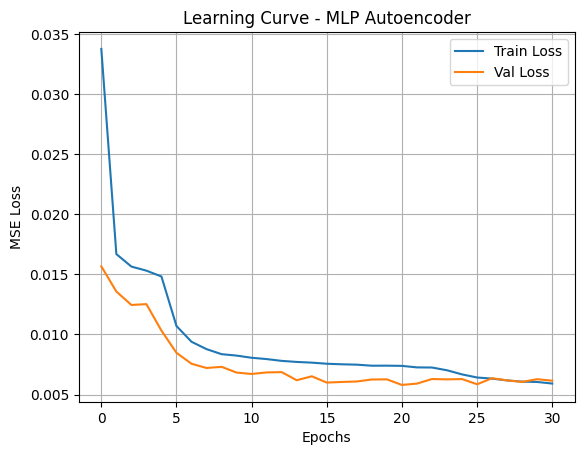

Best validation loss: 0.005803


In [92]:
# Loss graphic
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Learning Curve - MLP Autoencoder')
plt.legend()
plt.grid(True)
plt.show()

# the best val_loss
best_val_loss = min(history.history['val_loss'])
print(f"Best validation loss: {best_val_loss:.6f}")


In [ ]:
# plot_learning_curves(hist)

# Subtask 2.3

## CNN-based autoencoder

#### TODO
- Consider the size of the bottleneck layer equal to 2.

 - Develop your model and print `model.summary()`. Use 1D convolution, 1D pooling, and dense layers in the encoder and dense, 1D convolution transpose and 1D up-sampling layers in the decoder.
 - Train the model.
 - Select the best model based on the validation loss.
 - Plot the learning curves.
 - Report the best validation loss you obtained.

In [93]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D, Conv1DTranspose, Dense, Flatten, Reshape
from tensorflow.keras.optimizers import Adam

timesteps = X_train.shape[1]  # 32
features = X_train.shape[2]
bottleneck_size = 2

input_layer = Input(shape=(timesteps, features))

# Encoder
x = Conv1D(16, 3, activation='relu', padding='same')(input_layer)
x = MaxPooling1D(2, padding='same')(x)
x = Conv1D(8, 3, activation='relu', padding='same')(x)
x = MaxPooling1D(2, padding='same')(x)

shape_before_flatten = x.shape[1:]  # (timesteps_after_pooling, filters)
x = Flatten()(x)
encoded = Dense(bottleneck_size, activation='relu')(x)

# Decoder
x = Dense(shape_before_flatten[0] * shape_before_flatten[1], activation='relu')(encoded)
x = Reshape((shape_before_flatten[0], shape_before_flatten[1]))(x)
x = Conv1DTranspose(8, 3, strides=2, activation='relu', padding='same')(x)
x = UpSampling1D(2)(x)
x = Conv1DTranspose(16, 3, activation='relu', padding='same')(x)

decoded = Conv1D(features, 3, activation='sigmoid', padding='same')(x)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

autoencoder.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 32, 16)         │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 16, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 16, 8)          │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 8, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 8, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose                │ (None, 16, 8)          │           200 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 32, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_1              │ (None, 32, 16)         │           400 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 32, 7)          │           343 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,009 (7.85 KB)

 Trainable params: 2,009 (7.85 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
371/372 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0777

372/372 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0775 - val_loss: 0.0156
Epoch 2/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0190

372/372 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0190 - val_loss: 0.0143
Epoch 3/100
364/372 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0167

372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0167 - val_loss: 0.0130
Epoch 4/100
358/372 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0149

372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0148 - val_loss: 0.0118
Epoch 5/100
360/372 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0129

...

372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0074 - val_loss: 0.0073
Epoch 39/100
359/372 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0077

372/372 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0077 - val_loss: 0.0072
Epoch 40/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0075 - val_loss: 0.0076
Epoch 41/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0077 - val_loss: 0.0076
Epoch 42/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0072 - val_loss: 0.0074
Epoch 43/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0074 - val_loss: 0.0073
Epoch 44/100
354/372 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0075

372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0074 - val_loss: 0.0072
Epoch 45/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0073 - val_loss: 0.0074
Epoch 46/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0072 - val_loss: 0.0077
Epoch 47/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0073 - val_loss: 0.0072
Epoch 48/100
361/372 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0071

372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0071 - val_loss: 0.0071
Epoch 49/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0074 - val_loss: 0.0071
Epoch 50/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0074 - val_loss: 0.0072
Epoch 51/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0073 - val_loss: 0.0073
Epoch 52/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0072 - val_loss: 0.0073
Epoch 53/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0072 - val_loss: 0.0075
Epoch 54/100
368/372 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0072

372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0072 - val_loss: 0.0071
Epoch 55/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0072 - val_loss: 0.0071
Epoch 56/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0069 - val_loss: 0.0074
Epoch 57/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0071 - val_loss: 0.0072
Epoch 58/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0070 - val_loss: 0.0071
Epoch 59/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0070 - val_loss: 0.0080
Epoch 60/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0071 - val_loss: 0.0074
Epoch 61/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0071 - val_loss: 0.0072
Epoch 62/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0070 - val_loss: 0.0071
Epoch 63/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0069 - val_loss: 0.0072
Epoch 64/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0070 - val_loss: 0.0071


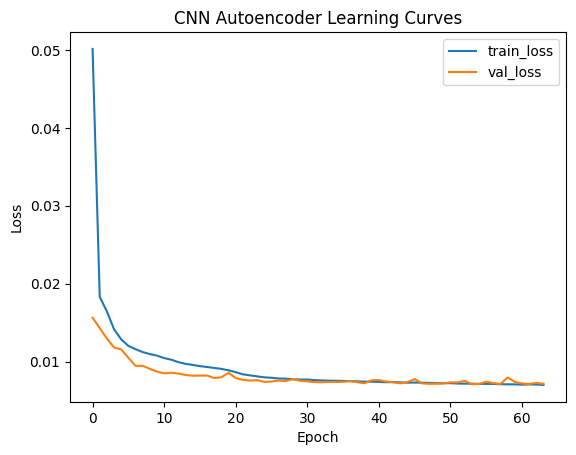

Best validation loss: 0.007076135836541653


In [95]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

checkpoint = ModelCheckpoint("best_cnn_autoencoder.h5", monitor='val_loss', save_best_only=True, mode='min')
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = autoencoder.fit(
    X_train, X_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, X_val),
    callbacks=[checkpoint, early_stop],
    verbose=1
)

# showing learning curve
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('CNN Autoencoder Learning Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

print("Best validation loss:", min(history.history['val_loss']))

In [ ]:
# plot_learning_curves(hist)

# Subtask 2.4

## Visualize the data in the latent space

#### TODO
 - Take the encoder part of the model as a new model.
 - Use the encoder to map the test data to the latent space.
 - Plot the latent variables versus each other.

 **Note:** Do not forget to add title, axis labels and a legend!
This applies in general, please keep in mind.

In [98]:
for i, layer in enumerate(autoencoder.layers):
    print(i, layer.name, layer.output)

0 input_layer_3 <KerasTensor shape=(None, 32, 7), dtype=float32, sparse=False, name=keras_tensor_27>
1 conv1d <KerasTensor shape=(None, 32, 16), dtype=float32, sparse=False, name=keras_tensor_28>
2 max_pooling1d <KerasTensor shape=(None, 16, 16), dtype=float32, sparse=False, name=keras_tensor_29>
3 conv1d_1 <KerasTensor shape=(None, 16, 8), dtype=float32, sparse=False, name=keras_tensor_30>
4 max_pooling1d_1 <KerasTensor shape=(None, 8, 8), dtype=float32, sparse=False, name=keras_tensor_31>
5 flatten_3 <KerasTensor shape=(None, 64), dtype=float32, sparse=False, name=keras_tensor_32>
6 dense_15 <KerasTensor shape=(None, 2), dtype=float32, sparse=False, name=keras_tensor_33>
7 dense_16 <KerasTensor shape=(None, 64), dtype=float32, sparse=False, name=keras_tensor_34>
8 reshape_3 <KerasTensor shape=(None, 8, 8), dtype=float32, sparse=False, name=keras_tensor_35>
9 conv1d_transpose <KerasTensor shape=(None, 16, 8), dtype=float32, sparse=False, name=keras_tensor_36>
10 up_sampling1d <KerasTe

In [99]:
from keras.models import Model

encoder = Model(inputs=autoencoder.input, outputs=autoencoder.get_layer("dense_15").output)

latent_test = encoder.predict(X_test)

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


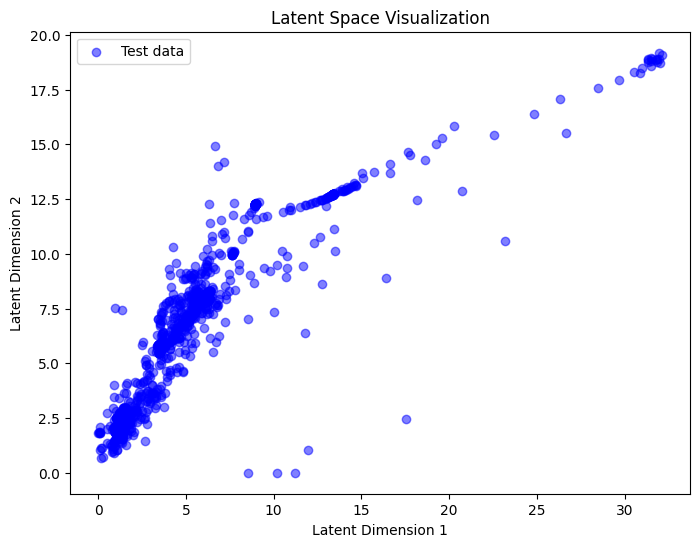

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(latent_test[:, 0], latent_test[:, 1], c='blue', alpha=0.5, label='Test data')
plt.title("Latent Space Visualization")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.legend()
plt.show()

# Subtask 2.5

## Size of the latent vector (bottleneck layer)

#### TODO
 - Use the CNN-based autoencoder.
 - Change the size of the bottleneck layer to 2, 4, 8, 16.
 - Train the model.
 - Select the best model based on the validation loss.
  - Report the best validation loss you obtained for each model.
 - Plot the best validation loss for each model versus the size of the bottleneck layer.

 **Note:** Do not forget to add title, axis labels and a legend!
This applies in general, please keep in mind.


In [101]:
from tensorflow.keras.callbacks import EarlyStopping

bottleneck_sizes = [2, 4, 8, 16]
best_val_losses = []

for size in bottleneck_sizes:
    # redefine the model
    # Encoder
    input_layer = Input(shape=(32, 7))
    x = Conv1D(16, 3, activation='relu', padding='same')(input_layer)
    x = MaxPooling1D(2, padding='same')(x)
    x = Conv1D(8, 3, activation='relu', padding='same')(x)
    x = MaxPooling1D(2, padding='same')(x)
    x = Flatten()(x)
    bottleneck = Dense(size, activation='relu', name='bottleneck')(x)  # Bottleneck boyutu değişiyor

    # Decoder
    x = Dense(8 * 8, activation='relu')(bottleneck)
    x = Reshape((8, 8))(x)
    x = Conv1DTranspose(8, 3, activation='relu', padding='same')(x)
    x = UpSampling1D(2)(x)
    x = Conv1DTranspose(16, 3, activation='relu', padding='same')(x)
    x = UpSampling1D(2)(x)
    output_layer = Conv1D(7, 3, activation='linear', padding='same')(x)

    autoencoder = Model(inputs=input_layer, outputs=output_layer)
    autoencoder.compile(optimizer='adam', loss='mse')

    # early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # train the model
    history = autoencoder.fit(
        X_train, X_train,  # Autoencoder, input and output are same
        validation_data=(X_val, X_val),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    # save the best val_loss
    best_val_loss = min(history.history['val_loss'])
    best_val_losses.append(best_val_loss)

    print(f"Bottleneck size: {size}, Best val loss: {best_val_loss:.5f}")


Bottleneck size: 2, Best val loss: 0.00680
Bottleneck size: 4, Best val loss: 0.00401
Bottleneck size: 8, Best val loss: 0.00359
Bottleneck size: 16, Best val loss: 0.00305


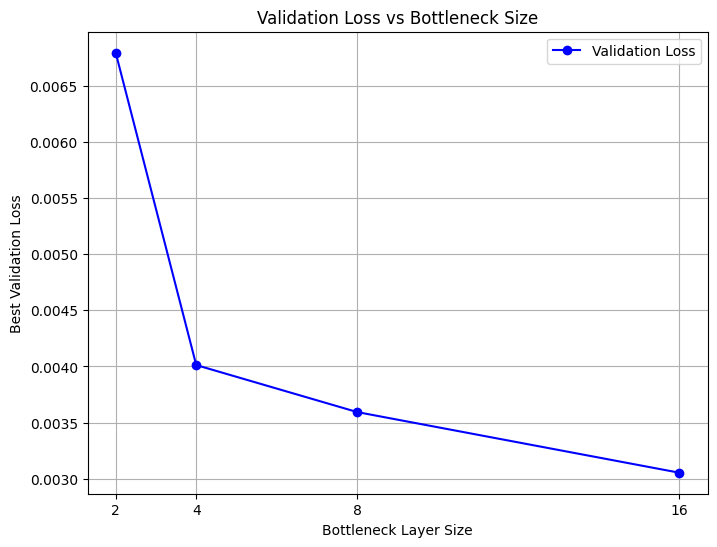

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(bottleneck_sizes, best_val_losses, marker='o', linestyle='-', color='b', label='Validation Loss')
plt.title("Validation Loss vs Bottleneck Size")
plt.xlabel("Bottleneck Layer Size")
plt.ylabel("Best Validation Loss")
plt.xticks(bottleneck_sizes)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# plot_learning_curves(hist)

# Subtask 2.6

## Scheduled learning rate

When training a model, it is often useful to lower the learning rate as the training progresses. A learning rate schedule is a predefined mechanism that adjusts the learning rate between optimization steps during the training. [`tf.keras.optimizers.schedules`](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/schedules) provides several methods.


#### TODO
 - Consider the size of the bottleneck layer equal to 2.
 - Change the optimizer to use an exponential decay schedule: `tf.keras.optimizers.schedules.ExponentialDecay`.
 - Set the initial learning rate equal to 0.01.
 - Train the model and report the lowest validation loss.



In [103]:
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Reshape, Conv1DTranspose, UpSampling1D
from tensorflow.keras.models import Model

# 1. Learning rate schedule
lr_schedule = ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True
)

optimizer = Adam(learning_rate=lr_schedule)

# 2. Model architecture (bottleneck size = 2)
input_layer = Input(shape=(32, 7))
x = Conv1D(16, 3, activation='relu', padding='same')(input_layer)
x = MaxPooling1D(2, padding='same')(x)
x = Conv1D(8, 3, activation='relu', padding='same')(x)
x = MaxPooling1D(2, padding='same')(x)
x = Flatten()(x)
bottleneck = Dense(2, activation='relu', name='bottleneck')(x)

x = Dense(64, activation='relu')(bottleneck)
x = Reshape((8, 8))(x)
x = Conv1DTranspose(8, 3, activation='relu', padding='same')(x)
x = UpSampling1D(2)(x)
x = Conv1DTranspose(16, 3, activation='relu', padding='same')(x)
x = UpSampling1D(2)(x)
output_layer = Conv1D(7, 3, activation='linear', padding='same')(x)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer=optimizer, loss='mse')

# 3. Training
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

In [104]:
best_val_loss = min(history.history['val_loss'])
print(f"Best validation loss with learning rate schedule: {best_val_loss:.5f}")

Best validation loss with learning rate schedule: 0.01460


In [ ]:
# plot_learning_curves(hist)

# Subtask 2.7

## Challenge

#### TODO
 - Use the CNN-based autoencoder.
 - Consider the size of the bottleneck layer equal to 8.
 - Modify the model architecture and the training process to obtain a better performance in reconstruction.
 - Select the best model based on the validation loss.
 - Plot the learning curves.
 - Report the best validation loss.

In [105]:
from tensorflow.keras.layers import BatchNormalization, Dropout, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

input_layer = Input(shape=(32, 7))

# Encoder
x = Conv1D(32, 3, padding='same')(input_layer)
x = LeakyReLU()(x)
x = BatchNormalization()(x)
x = MaxPooling1D(2, padding='same')(x)

x = Conv1D(16, 3, padding='same')(x)
x = LeakyReLU()(x)
x = BatchNormalization()(x)
x = MaxPooling1D(2, padding='same')(x)

x = Flatten()(x)
x = Dense(64)(x)
x = LeakyReLU()(x)
x = Dropout(0.3)(x)
bottleneck = Dense(8, activation='relu', name='bottleneck')(x)

# Decoder
x = Dense(64)(bottleneck)
x = LeakyReLU()(x)
x = Reshape((8, 8))(x)

x = Conv1DTranspose(16, 3, padding='same')(x)
x = LeakyReLU()(x)
x = UpSampling1D(2)(x)

x = Conv1DTranspose(32, 3, padding='same')(x)
x = LeakyReLU()(x)
x = UpSampling1D(2)(x)

output_layer = Conv1D(7, 3, activation='linear', padding='same')(x)

# Model
autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_plateau = ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, verbose=1)

# Training
history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, lr_plateau],
    verbose=0
)


Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 33: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 39: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 44: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 49: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.


Best validation loss with bottleneck size 8 (improved): 0.00327


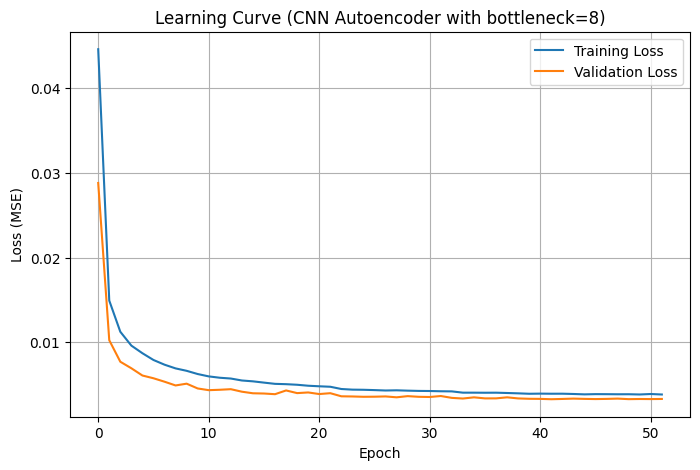

In [106]:
import matplotlib.pyplot as plt

# the best val_loss
best_val_loss = min(history.history['val_loss'])
print(f"Best validation loss with bottleneck size 8 (improved): {best_val_loss:.5f}")

# learning curve
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Learning Curve (CNN Autoencoder with bottleneck=8)")
plt.legend()
plt.grid(True)
plt.show()

# Subtask 2.8

## Reconstruction loss

#### TODO
 - Use the best model you have trained.
 - Compute the reconstruction loss for validation and test dataset.
    - You need to compute the loss for every time step.



In [107]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Guess the Val and Test
val_pred = autoencoder.predict(X_val)
test_pred = autoencoder.predict(X_test)

# MSE
# shape: (num_samples, time_steps, features) -> loss: (num_samples, time_steps)
val_loss_per_timestep = np.mean((X_val - val_pred)**2, axis=-1)
test_loss_per_timestep = np.mean((X_test - test_pred)**2, axis=-1)


91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


Mean reconstruction loss per timestep (validation):
[0.00526328 0.00379171 0.00343103 0.00317371 0.00312091 0.00317281
 0.00313497 0.0032108  0.00323361 0.00307773 0.00301167 0.00306019
 0.00301778 0.00308968 0.00307678 0.00297291 0.00276806 0.00259629
 0.00287708 0.00313588 0.00334452 0.00330923 0.00323396 0.00324463
 0.0030958  0.00308463 0.00304083 0.00306824 0.00318932 0.00337186
 0.00371578 0.00480398]

Mean reconstruction loss per timestep (test):
[0.01919952 0.01761069 0.01628287 0.01486671 0.01466574 0.01417889
 0.01423854 0.01387414 0.01387624 0.01489465 0.01498648 0.01596948
 0.01652674 0.01651365 0.0157452  0.0153446  0.01534703 0.01553553
 0.01516407 0.01471394 0.01495871 0.01369215 0.01305993 0.0130337
 0.01275857 0.01305934 0.01304263 0.01352772 0.01335001 0.01469545
 0.01524651 0.01680866]


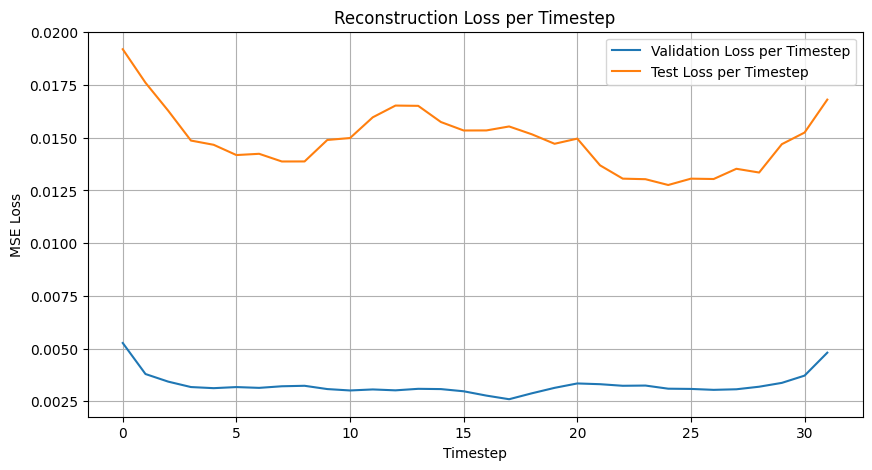

In [108]:
import matplotlib.pyplot as plt

# Ortalama reconstruction loss per timestep
mean_val_loss = np.mean(val_loss_per_timestep, axis=0)
mean_test_loss = np.mean(test_loss_per_timestep, axis=0)

print("Mean reconstruction loss per timestep (validation):")
print(mean_val_loss)

print("\nMean reconstruction loss per timestep (test):")
print(mean_test_loss)

# visualization
plt.figure(figsize=(10, 5))
plt.plot(mean_val_loss, label="Validation Loss per Timestep")
plt.plot(mean_test_loss, label="Test Loss per Timestep")
plt.xlabel("Timestep")
plt.ylabel("MSE Loss")
plt.title("Reconstruction Loss per Timestep")
plt.legend()
plt.grid(True)
plt.show()


# Subtask 2.9

## Anomaly detection

#### TDOD
- Use the test dataset.
- Plot the ROC and precision-recall curves and report the area under the curve (AUC) for each of them.
- Select the threshold by allowing a false positive rate of 0.2.
- Detect anomalies using the threshold.

In [117]:
# print(y_test.shape)
# print(y_test[:5])

print(len(y_test))
print(y_test[:1])

y_test_array = y_test[0]
y_test_array

6
[array([ True,  True,  True, ...,  True,  True,  True])]


array([ True,  True,  True, ...,  True,  True,  True])

In [120]:
sequence_len = X_test.shape[1]
sequence_len

32

In [128]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# flatten the y_test
y_test_array = np.concatenate(y_test)

reconstruction_errors = np.mean((X_test - test_pred) ** 2, axis=(1, 2))

#ROC
reconstruction_errors = reconstruction_errors.flatten()
y_test_array = y_test_array[-len(reconstruction_errors):]
fpr, tpr, roc_thresholds = roc_curve(y_test_array, reconstruction_errors)
roc_auc = auc(fpr, tpr)

precision, recall, pr_thresholds = precision_recall_curve(y_test_array, reconstruction_errors)
pr_auc = auc(recall, precision)

print("ROC AUC:", roc_auc)
print("PR AUC:", pr_auc)

ROC AUC: 0.5855759406729533
PR AUC: 0.6831369291845362


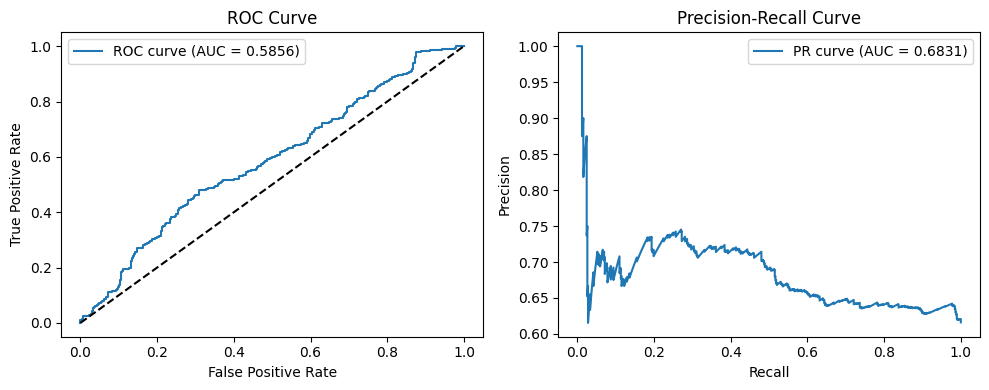

In [129]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

# Precision-Recall plot
plt.subplot(1, 2, 2)
plt.plot(recall, precision, label=f"PR curve (AUC = {pr_auc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

# Subtask 2.10

## Evaluate model performance

#### TODO
 - Compute accuracy, recall, precision f1-score.
 - Explain the effect of selecting different values for the threshold on the performance of the model.

In [130]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [131]:
fpr, tpr, thresholds = roc_curve(y_test_array, reconstruction_errors)

# FPR <= 0.2
allowed_fpr = 0.2
idx = (fpr <= allowed_fpr).nonzero()[0][-1]  # son uygun indeks
threshold = thresholds[idx]

# guess
y_pred = (reconstruction_errors >= threshold).astype(int)
y_true = y_test_array.astype(int)

In [132]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Threshold: {threshold:.4f}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Threshold: 0.0079
Accuracy:  0.4989
Precision: 0.7149
Recall:    0.3106
F1-Score:  0.4331


# <span style='color:red'>**Explanation:**</span>

When a low threshold value is chosen, the model makes more positive predictions; this leads to detecting more true anomalies (high recall), but at the same time, the number of false positives may increase (low precision).
On the other hand, a high threshold value causes the model to respond as anomalous only to large reconstruction errors; thus, false positives decrease, but true anomalies might be missed (low recall).
Therefore, the choice of threshold determines the balance between precision and recall, and it should be optimized according to the specific use case.

## Visualize the detected anomalies

#### TDOD
 - Plot `Trq_MeanEff_Engine[Nm]` for the behavior `FP75`:
 - Visualize the healthy time steps by green.
 - Visualize the `GainRPMx2` true anomalous time steps by yellow, alpha: 0.3, and line width: 6.
 - Visualize the predicted anomalous time steps by red.

In [ ]:
####################
## YOUR CODE HERE ##
####################